# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [3]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

# Define the Training and Target Cols 

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt",
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# DataFrames + Splitting + Scaling

In [6]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [7]:
# Splitting :
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)

print("SPLITS df_all:")
print("train:", df_train_all.shape, df_train_all["class"].value_counts().to_dict())
print("val  :", df_val_all.shape,   df_val_all["class"].value_counts().to_dict())
print("test :", df_test_all.shape,  df_test_all["class"].value_counts().to_dict())

df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("SPLITS df_bal:")
print("train:", df_train_bal.shape, df_train_bal["class"].value_counts().to_dict())
print("val  :", df_val_bal.shape,   df_val_bal["class"].value_counts().to_dict())
print("test :", df_test_bal.shape,  df_test_bal["class"].value_counts().to_dict())

SPLITS df_all:
train: (269880, 76) {1: 204276, 0: 65604}
val  : (33735, 76) {1: 25636, 0: 8099}
test : (33736, 76) {1: 25492, 0: 8244}
SPLITS df_bal:
train: (131115, 76) {1: 65596, 0: 65519}
val  : (16389, 76) {0: 8228, 1: 8161}
test : (16390, 76) {0: 8200, 1: 8190}


In [8]:
# Scaling :
SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

OUTDIR = "../results/prepared_splits"   # relativo a notebooks/
os.makedirs(OUTDIR, exist_ok=True)

In [13]:
RUN_TAG = "pat100"
RUN_SUFFIX = f"_{RUN_TAG}"

RUNS_OUTDIR = "../results/runs_prepared"
os.makedirs(RUNS_OUTDIR, exist_ok=True)

In [14]:
paths_unbalanced = data.apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = data.apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/balanced/X_NONE__Y_LOCAL


# Trainings 

In [15]:
def load_prepared(mode_dir: str):
    df_tr = pd.read_pickle(os.path.join(mode_dir, "train.pkl"))
    df_va = pd.read_pickle(os.path.join(mode_dir, "val.pkl"))
    df_te = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
    scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))
    return df_tr, df_va, df_te, scalers

In [17]:
# Balanced MSE pat30
results_balanced_mse_pat30 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — MSE pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=30,
    )

    results_balanced_mse_pat30[mode] = res

# Balanced MSE pat 100

results_balanced_mse_pat100 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — MSE pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="mse",
        patience=100,
    )

    results_balanced_mse_pat100[mode] = res

# Balanced HUBER pat 30
results_balanced_huber_pat30 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — HUBER pat30")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=30,
    )

    results_balanced_huber_pat30[mode] = res

# Balanced HUBER pat 100
results_balanced_huber_pat100 = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} — HUBER pat100")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",
        huber_delta=1.0,
        patience=100,
    )

    results_balanced_huber_pat100[mode] = res


TRAIN BALANCED — X_NONE__Y_NONE (pat100)
[ep    1] train=3.687908  val=1.421214  best=1.421214  bad=0/100
[ep   10] train=1.092007  val=1.746598  best=1.084136  bad=7/100
[ep   20] train=1.023091  val=1.083234  best=1.006036  bad=4/100
[ep   30] train=0.942444  val=0.947992  best=0.909171  bad=9/100
[ep   40] train=0.887808  val=1.057296  best=0.860921  bad=6/100
[ep   50] train=0.907978  val=2.070304  best=0.729819  bad=2/100
[ep   60] train=0.682551  val=1.242771  best=0.626643  bad=1/100
[ep   70] train=0.658702  val=0.762869  best=0.575737  bad=2/100
[ep   80] train=0.629494  val=0.835763  best=0.562905  bad=9/100
[ep   90] train=0.627498  val=1.061923  best=0.514836  bad=4/100
[ep  100] train=0.682706  val=0.835504  best=0.514836  bad=14/100
[ep  110] train=0.577663  val=0.686386  best=0.514836  bad=24/100
[ep  120] train=0.608505  val=0.908415  best=0.514836  bad=34/100
[ep  130] train=0.585042  val=0.655194  best=0.475697  bad=5/100
[ep  140] train=0.570629  val=0.476288  best=

In [18]:
results_unbalanced = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} ({RUN_TAG})")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
    )

    results_unbalanced[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE (pat100)
[ep    1] train=5.294066  val=1.134624  best=1.134624  bad=0/100
[ep   10] train=1.012400  val=0.970665  best=0.970665  bad=0/100
[ep   20] train=0.807245  val=0.765669  best=0.765669  bad=0/100
[ep   30] train=0.692294  val=0.645242  best=0.645242  bad=0/100
[ep   40] train=0.659121  val=0.630408  best=0.605995  bad=1/100
[ep   50] train=0.680432  val=0.630435  best=0.605995  bad=11/100
[ep   60] train=0.609062  val=0.622891  best=0.584520  bad=2/100
[ep   70] train=0.560476  val=0.549251  best=0.549251  bad=0/100
[ep   80] train=0.565313  val=0.524259  best=0.524259  bad=0/100
[ep   90] train=0.559969  val=0.587071  best=0.518656  bad=3/100
[ep  100] train=0.533603  val=0.526814  best=0.511999  bad=8/100
[ep  110] train=0.533351  val=0.565483  best=0.496369  bad=3/100
[ep  120] train=0.520888  val=0.520055  best=0.496369  bad=13/100
[ep  130] train=0.666957  val=0.560955  best=0.496369  bad=23/100
[ep  140] train=0.507491  val=0.519534  bes

In [19]:
# Salvo i run :
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"

for mode, res in results_balanced.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode + RUN_SUFFIX)
    os.makedirs(save_dir, exist_ok=True)

    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/balanced/X_NONE__Y_NONE_pat100
saved -> ../results/runs_prepared/balanced/X_GLOBAL__Y_LOCAL_pat100
saved -> ../results/runs_prepared/balanced/X_GLOBAL__Y_GLOBAL_pat100
saved -> ../results/runs_prepared/balanced/X_LOCAL__Y_LOCAL_pat100
saved -> ../results/runs_prepared/balanced/X_NONE__Y_LOCAL_pat100


In [20]:
dataset_tag = "unbalanced"

for mode, res in results_unbalanced.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode + RUN_SUFFIX)
    os.makedirs(save_dir, exist_ok=True)

    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/unbalanced/X_NONE__Y_NONE_pat100
saved -> ../results/runs_prepared/unbalanced/X_GLOBAL__Y_LOCAL_pat100
saved -> ../results/runs_prepared/unbalanced/X_GLOBAL__Y_GLOBAL_pat100
saved -> ../results/runs_prepared/unbalanced/X_LOCAL__Y_LOCAL_pat100
saved -> ../results/runs_prepared/unbalanced/X_NONE__Y_LOCAL_pat100


In [21]:
# test to check if I saved it correctly:
res_check = training.load_run(
    f"../results/runs_prepared/balanced/X_NONE__Y_NONE{RUN_SUFFIX}"
)

df_pred_check = model.predict_tau_corr_auto(
    df=df_test_bal,   # raw
    res=res_check,
    train_cols=train_cols,
    y_cols=y_cols,
)

df_pred_check.head()

,tau1_corr_pred,tau2_corr_pred
0,1.564309,2.087035
1,0.561360,1.126835
2,1.375500,1.358348
3,0.886419,1.112816
4,1.297643,1.436273


# Predictions

In [22]:
preds_bal = {}

for mode in SCALING_MODES:
    res = results_balanced[mode]
    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,   # RAW
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        n_steps=60,
        batch_size=8192,
    )
    preds_bal[mode] = df_pred
    print(mode, "done", df_pred.shape)


preds_unbal = {}

for mode in SCALING_MODES:
    res = results_unbalanced[mode]
    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,   
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
        n_steps=60,
        batch_size=8192,
    )
    preds_unbal[mode] = df_pred
    print(mode, "done", df_pred.shape)

X_NONE__Y_NONE done (16390, 2)
X_GLOBAL__Y_LOCAL done (16390, 2)
X_GLOBAL__Y_GLOBAL done (16390, 2)
X_LOCAL__Y_LOCAL done (16390, 2)
X_NONE__Y_LOCAL done (16390, 2)
X_NONE__Y_NONE done (33736, 2)
X_GLOBAL__Y_LOCAL done (33736, 2)
X_GLOBAL__Y_GLOBAL done (33736, 2)
X_LOCAL__Y_LOCAL done (33736, 2)
X_NONE__Y_LOCAL done (33736, 2)


In [17]:
# sanity check :

for mode, dfp in preds_bal.items():
    r1 = dfp["tau1_corr_pred"].to_numpy()
    r2 = dfp["tau2_corr_pred"].to_numpy()
    print(mode,
          "mean:", float((r1.mean()+r2.mean())/2), # should be around 1
          "neg_frac:", float(np.mean((r1<0) | (r2<0)))) # should be around 0

X_NONE__Y_NONE mean: 1.254673957824707 neg_frac: 0.005308114704087858
X_GLOBAL__Y_LOCAL mean: 1.2780402898788452 neg_frac: 0.0
X_GLOBAL__Y_GLOBAL mean: 1.2891082763671875 neg_frac: 0.0
X_LOCAL__Y_LOCAL mean: 1.2856090068817139 neg_frac: 0.0
X_NONE__Y_LOCAL mean: 1.3289475440979004 neg_frac: 6.101281269066504e-05


# Plots

In [23]:
masses_bal = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal[mode] = m
    print(mode, "done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE done: 110.88305699601112 30.47738535508715
X_GLOBAL__Y_LOCAL done: 110.16122514123124 24.323225530664292
X_GLOBAL__Y_GLOBAL done: 111.91230314021544 24.76928268551943
X_LOCAL__Y_LOCAL done: 110.83880008344718 25.744056744935566
X_NONE__Y_LOCAL done: 113.75119959975329 30.98180040034168


In [24]:
masses_unbal = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal[mode] = m
    print(mode, "done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE done: 119.13096949922661 22.61622402366381
X_GLOBAL__Y_LOCAL done: 117.10754261325823 17.100276876372533
X_GLOBAL__Y_GLOBAL done: 118.0903070516347 17.148229033068112
X_LOCAL__Y_LOCAL done: 117.58440115548673 18.065072799623888
X_NONE__Y_LOCAL done: 116.65200733356421 21.16510569029451


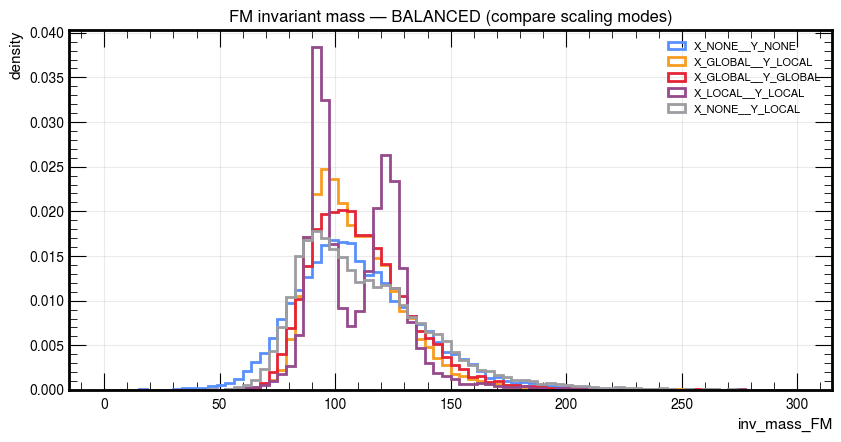

In [25]:
massesPlots.plot_mass_overlay(
    masses_bal,
    title="FM invariant mass — BALANCED (compare scaling modes)",
    bins=80,
    range_=(0, 300), 
    density=True,
)

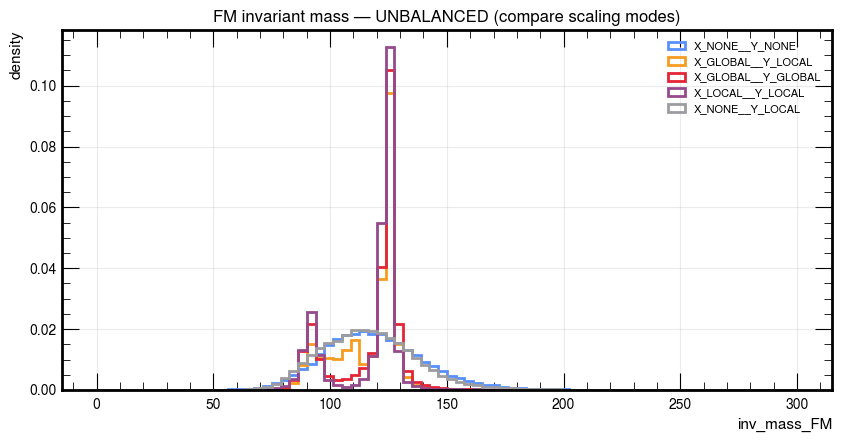

In [26]:
massesPlots.plot_mass_overlay(
    masses_unbal,
    title="FM invariant mass — UNBALANCED (compare scaling modes)",
    bins=80,
    range_=(0, 300),
    density=True,
)

In [27]:
m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

# BALANCED
masses_bal_dy = {mode: np.asarray(masses_bal[mode])[m_dy_bal] for mode in SCALING_MODES}
masses_bal_h  = {mode: np.asarray(masses_bal[mode])[m_h_bal]  for mode in SCALING_MODES}

# UNBALANCED
masses_unb_dy = {mode: np.asarray(masses_unbal[mode])[m_dy_unb] for mode in SCALING_MODES}
masses_unb_h  = {mode: np.asarray(masses_unbal[mode])[m_h_unb]  for mode in SCALING_MODES}

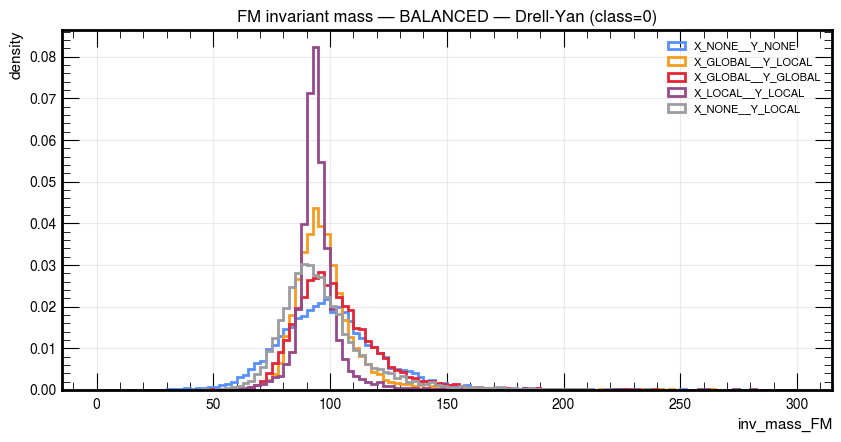

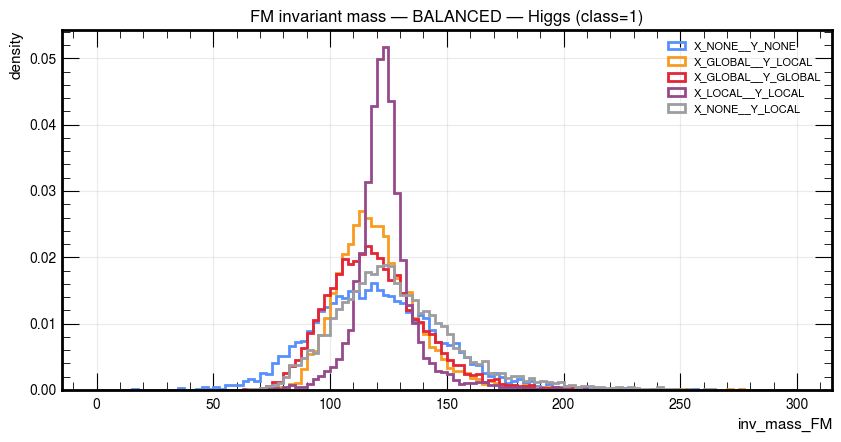

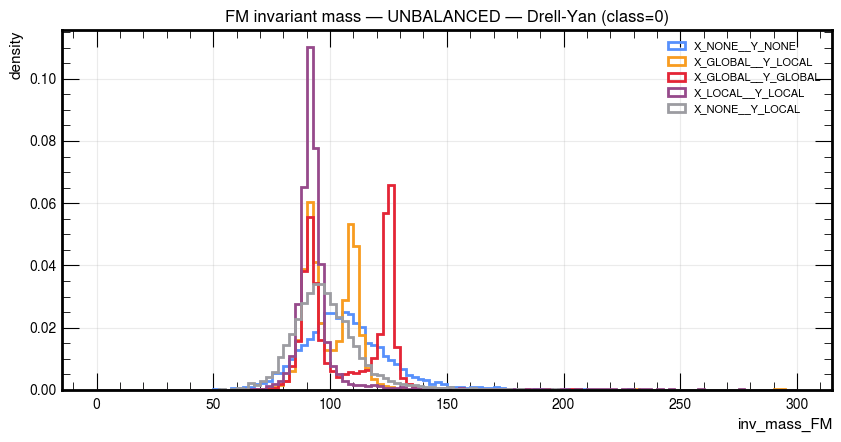

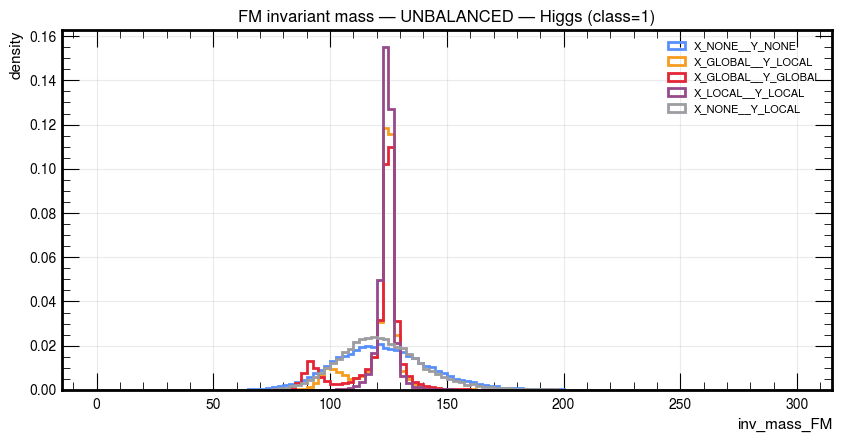

In [28]:
common_range = (0, 300) 

# BALANCED
massesPlots.plot_mass_overlay(
    masses_bal_dy,
    title="FM invariant mass — BALANCED — Drell-Yan (class=0)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_bal_h,
    title="FM invariant mass — BALANCED — Higgs (class=1)",
    bins=120,
    range_=common_range,
    density=True,
)

# UNBALANCED
massesPlots.plot_mass_overlay(
    masses_unb_dy,
    title="FM invariant mass — UNBALANCED — Drell-Yan (class=0)",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unb_h,
    title="FM invariant mass — UNBALANCED — Higgs (class=1)",
    bins=120,
    range_=common_range,
    density=True,
)

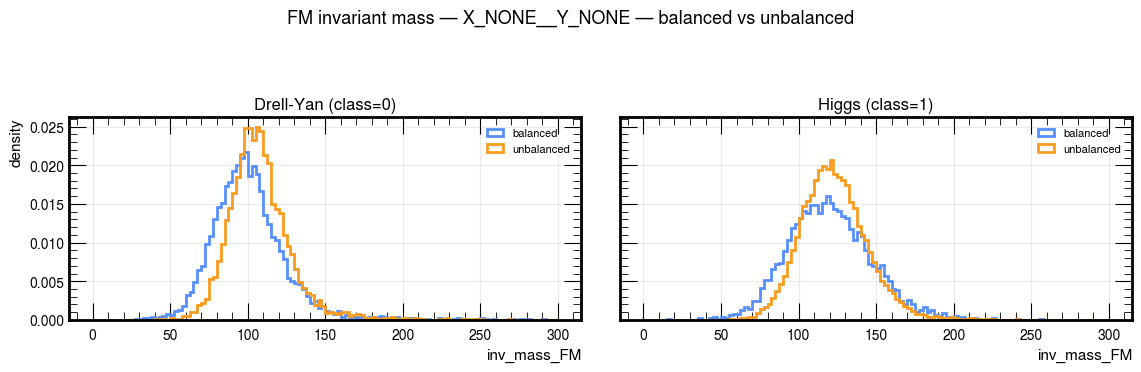

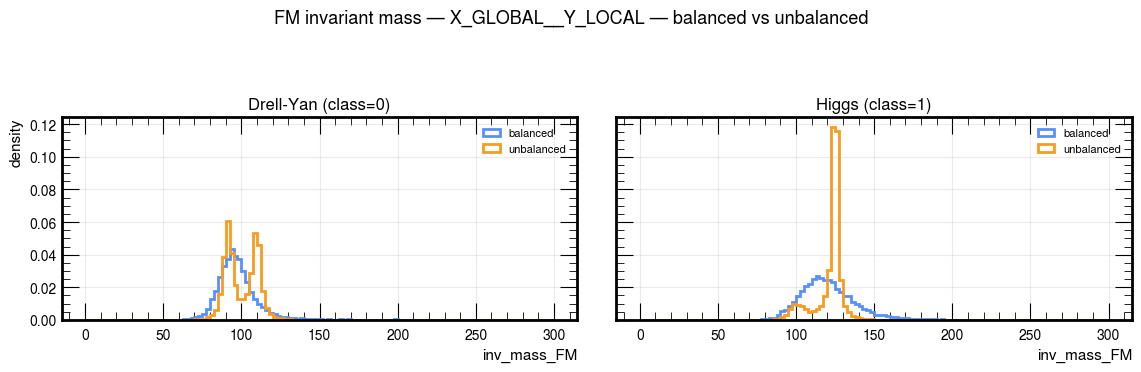

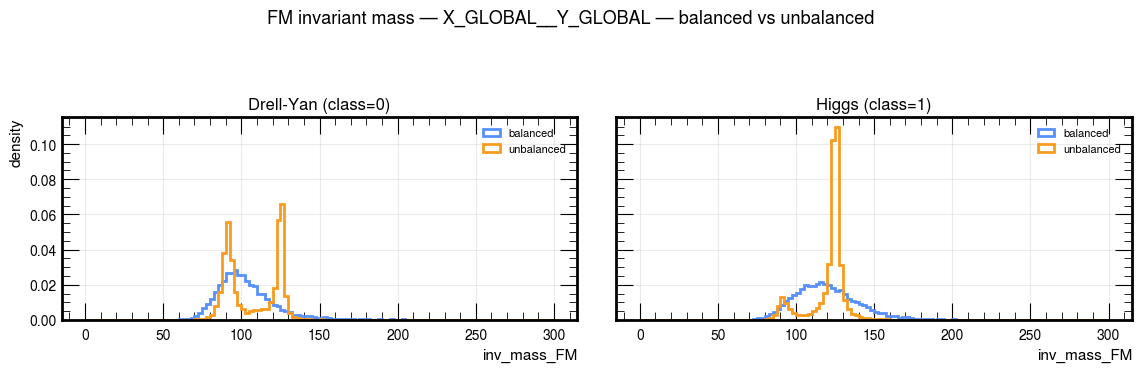

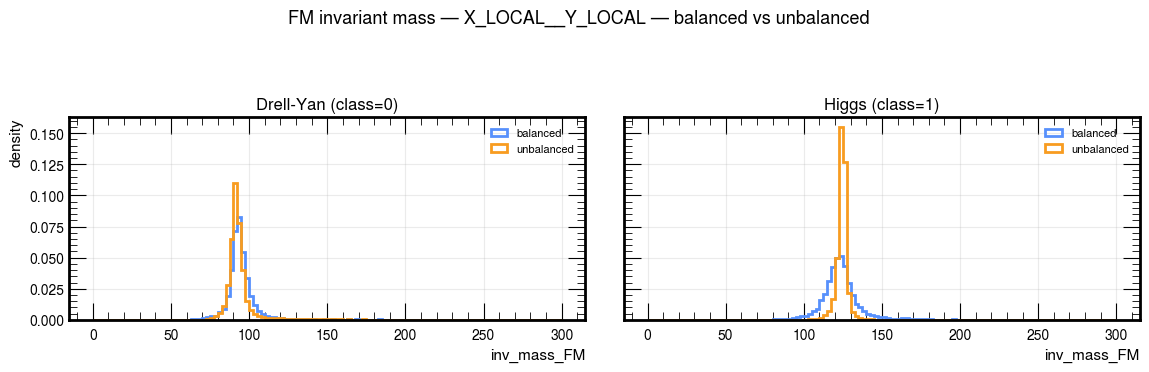

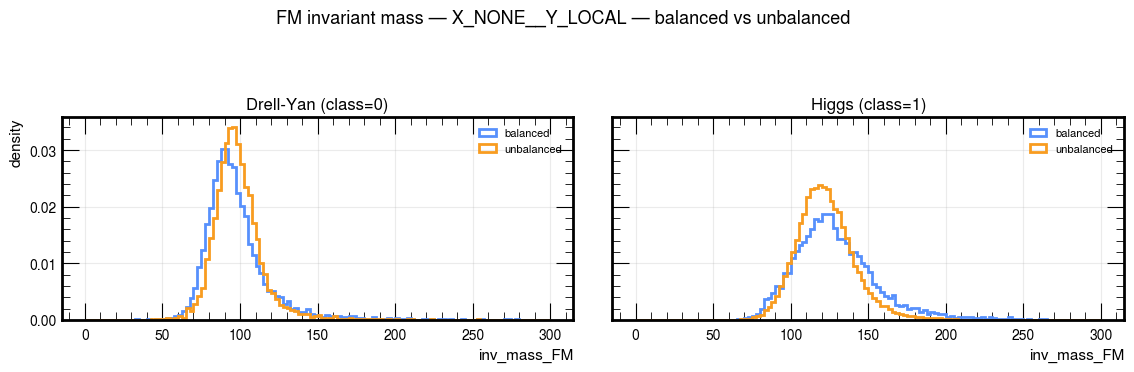

In [29]:
massesPlots.plot_balanced_vs_unbalanced_by_mode(
    masses_bal=masses_bal,
    masses_unbal=masses_unbal,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    bins=120,
    range_=(0, 300), 
    density=True,
)

In [30]:
# Saving the masses - new (uso un nome inequivocabile per quando farò fine-tuning):
OUT = "../results/masses"
os.makedirs(OUT, exist_ok=True)

np.savez_compressed(
    os.path.join(OUT, "masses_bal_nonflat_mse_verified.npz"),
    **{mode: np.asarray(masses_bal[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, "masses_unbal_nonflat_mse_verified.npz"),
    **{mode: np.asarray(masses_unbal[mode]) for mode in SCALING_MODES}
)

print("Saved verified non-flat MSE masses ->", OUT)

Saved verified non-flat MSE masses -> ../results/masses


In [31]:
# Salvo separatamente le masse Higgs e Drell-Yan così da poterle riutilizzare:
# masks balanced
m_dy_bal = df_test_bal["class"].to_numpy() == 0
m_h_bal  = df_test_bal["class"].to_numpy() == 1

# masks unbalanced
m_dy_unb = df_test_all["class"].to_numpy() == 0
m_h_unb  = df_test_all["class"].to_numpy() == 1

# split masses by class
masses_bal_dy = {
    mode: np.asarray(masses_bal[mode])[m_dy_bal]
    for mode in SCALING_MODES
}
masses_bal_h = {
    mode: np.asarray(masses_bal[mode])[m_h_bal]
    for mode in SCALING_MODES
}

masses_unbal_dy = {
    mode: np.asarray(masses_unbal[mode])[m_dy_unb]
    for mode in SCALING_MODES
}
masses_unbal_h = {
    mode: np.asarray(masses_unbal[mode])[m_h_unb]
    for mode in SCALING_MODES
}

OUT = "../results/masses"
os.makedirs(OUT, exist_ok=True)

np.savez_compressed(
    os.path.join(OUT, f"masses_bal_nonflat_mse_dy{RUN_SUFFIX}.npz"),
    **{mode: np.asarray(masses_bal_dy[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, f"masses_bal_nonflat_mse_h{RUN_SUFFIX}.npz"),
    **{mode: np.asarray(masses_bal_h[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, f"masses_unbal_nonflat_mse_dy{RUN_SUFFIX}.npz"),
    **{mode: np.asarray(masses_unbal_dy[mode]) for mode in SCALING_MODES}
)

np.savez_compressed(
    os.path.join(OUT, f"masses_unbal_nonflat_mse_h{RUN_SUFFIX}.npz"),
    **{mode: np.asarray(masses_unbal_h[mode]) for mode in SCALING_MODES}
)

print(f"Saved class-separated non-flat MSE masses ({RUN_TAG}).")

Saved class-separated non-flat MSE masses (pat100).


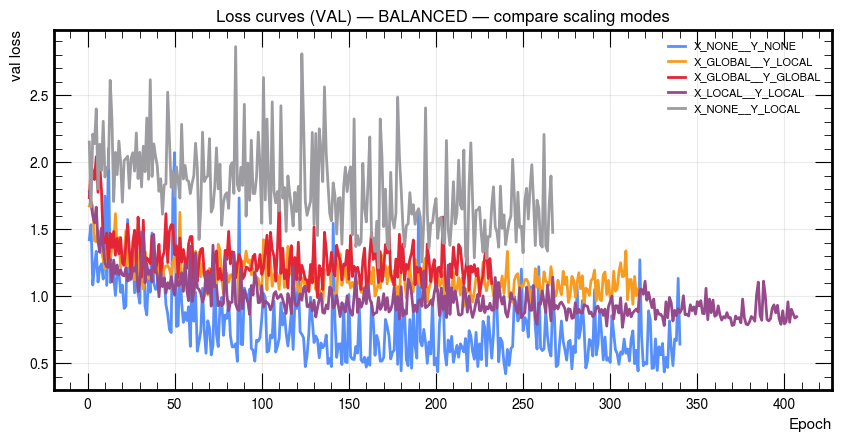

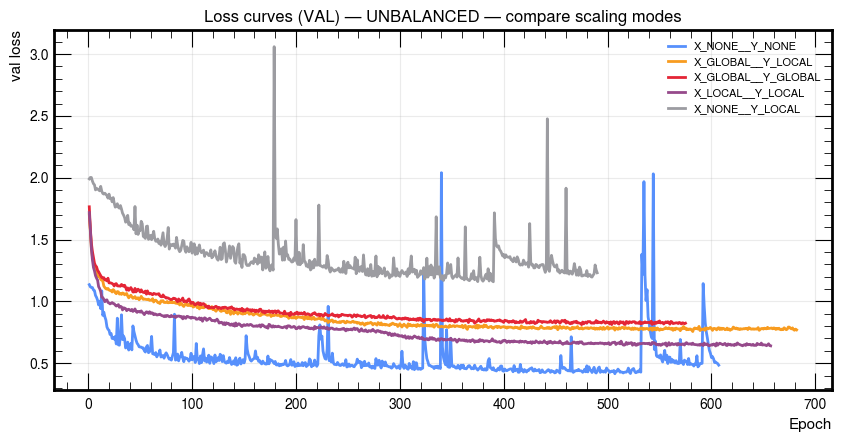

In [32]:
lossPlots.plot_loss_overlay(
    results_balanced,
    title="Loss curves (VAL) — BALANCED — compare scaling modes",
    which="val",
    logy=False,      
)

lossPlots.plot_loss_overlay(
    results_unbalanced,
    title="Loss curves (VAL) — UNBALANCED — compare scaling modes",
    which="val",
)

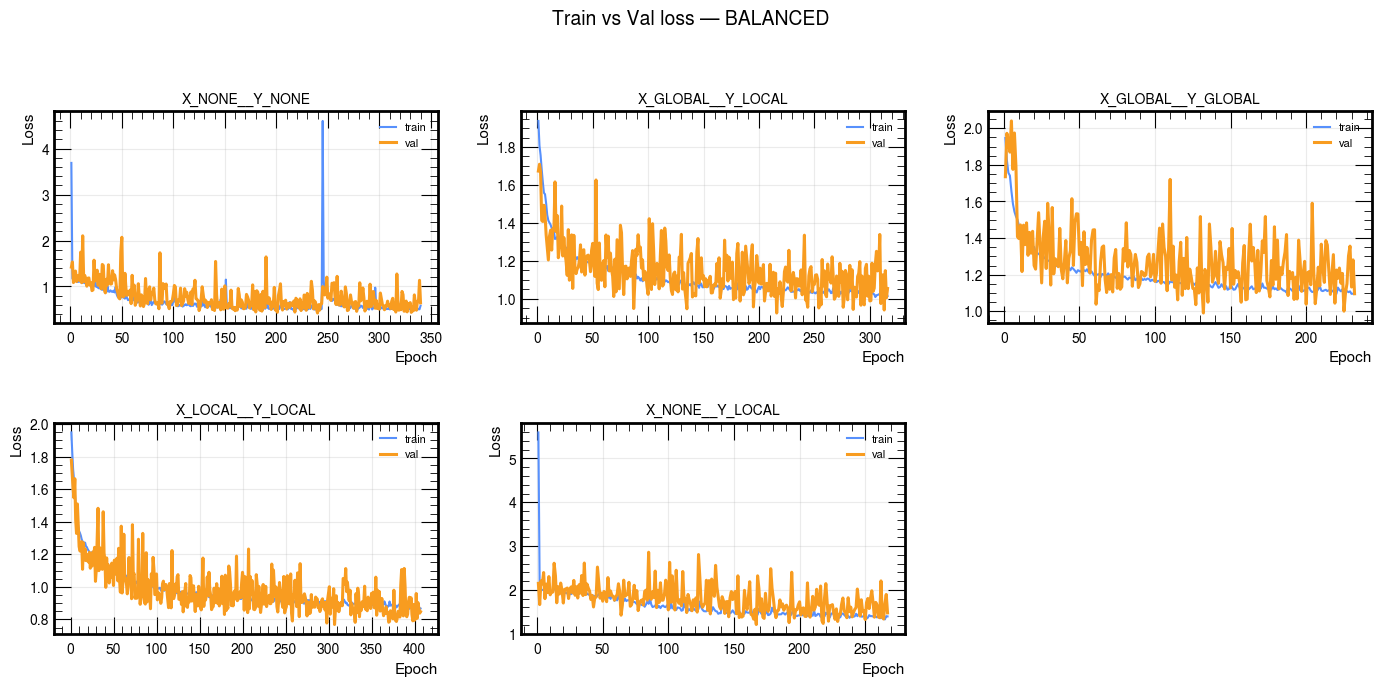

In [33]:
lossPlots.plot_loss_grid(
    results_balanced,
    title="Train vs Val loss — BALANCED",
    order=SCALING_MODES,
    ncols=3,
)

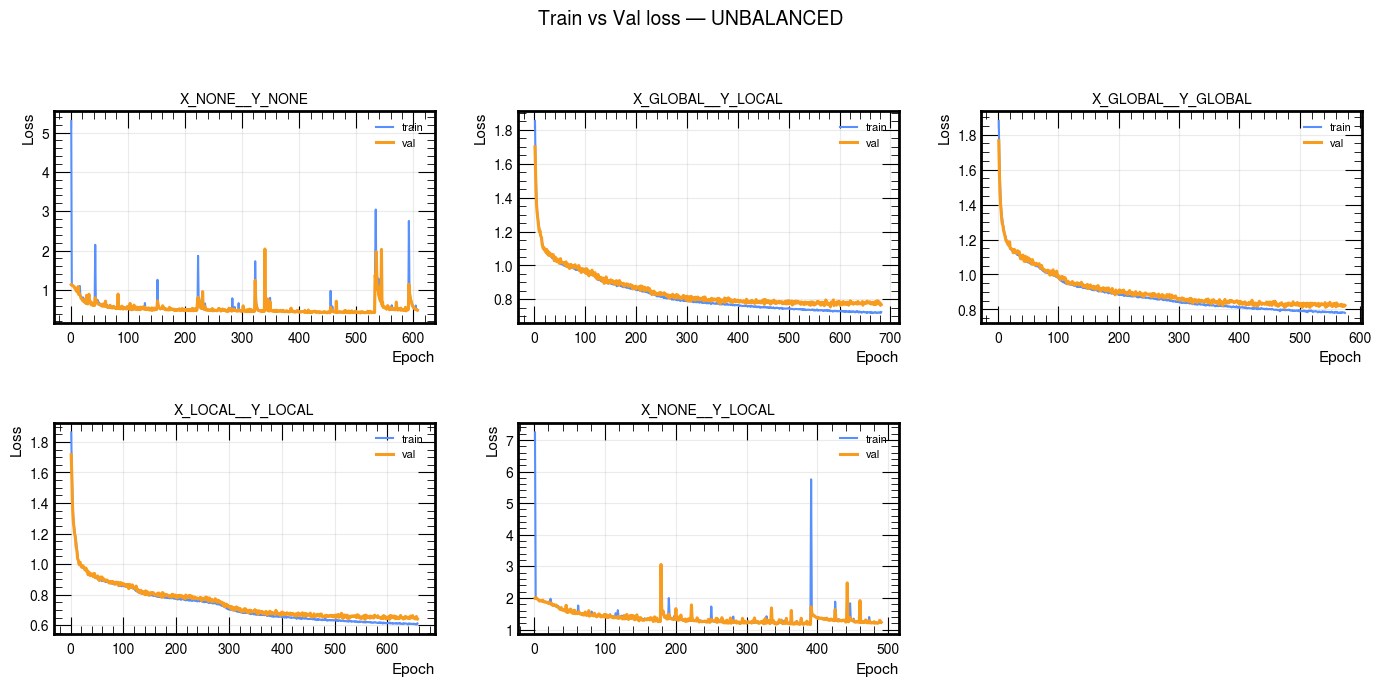

In [34]:
lossPlots.plot_loss_grid(
    results_unbalanced,
    title="Train vs Val loss — UNBALANCED",
    order=SCALING_MODES,
    ncols=3,
)

# Analysis
- S/B within the window (110-130) GeV

In [35]:
print("S/B:")
tab_long, tab_pivot = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal,
    masses_unbal=masses_unbal,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110,140),
    save_csv=True,
)

tab_pivot

S/B:


,mode,balanced,unbalanced
0,X_GLOBAL__Y_GLOBAL,2.222162,5.480133
1,X_GLOBAL__Y_LOCAL,5.503973,13.202907
2,X_LOCAL__Y_LOCAL,21.684543,111.163717
3,X_NONE__Y_LOCAL,3.533214,12.949367
4,X_NONE__Y_NONE,1.802369,4.935425


## CHECK :

In [36]:
# Conto separatamente S e B per il best mode:
tab_long[tab_long["mode"] == "X_LOCAL__Y_LOCAL"]

,dataset,mode,window,N_S,N_B,S_over_B,S_over_sqrtB
6,balanced,X_LOCAL__Y_LOCAL,110-140,6874,317,21.684543,386.082304
7,unbalanced,X_LOCAL__Y_LOCAL,110-140,25123,226,111.163717,1671.157101


# Scaling Tests

## y distribution pre/post scaling

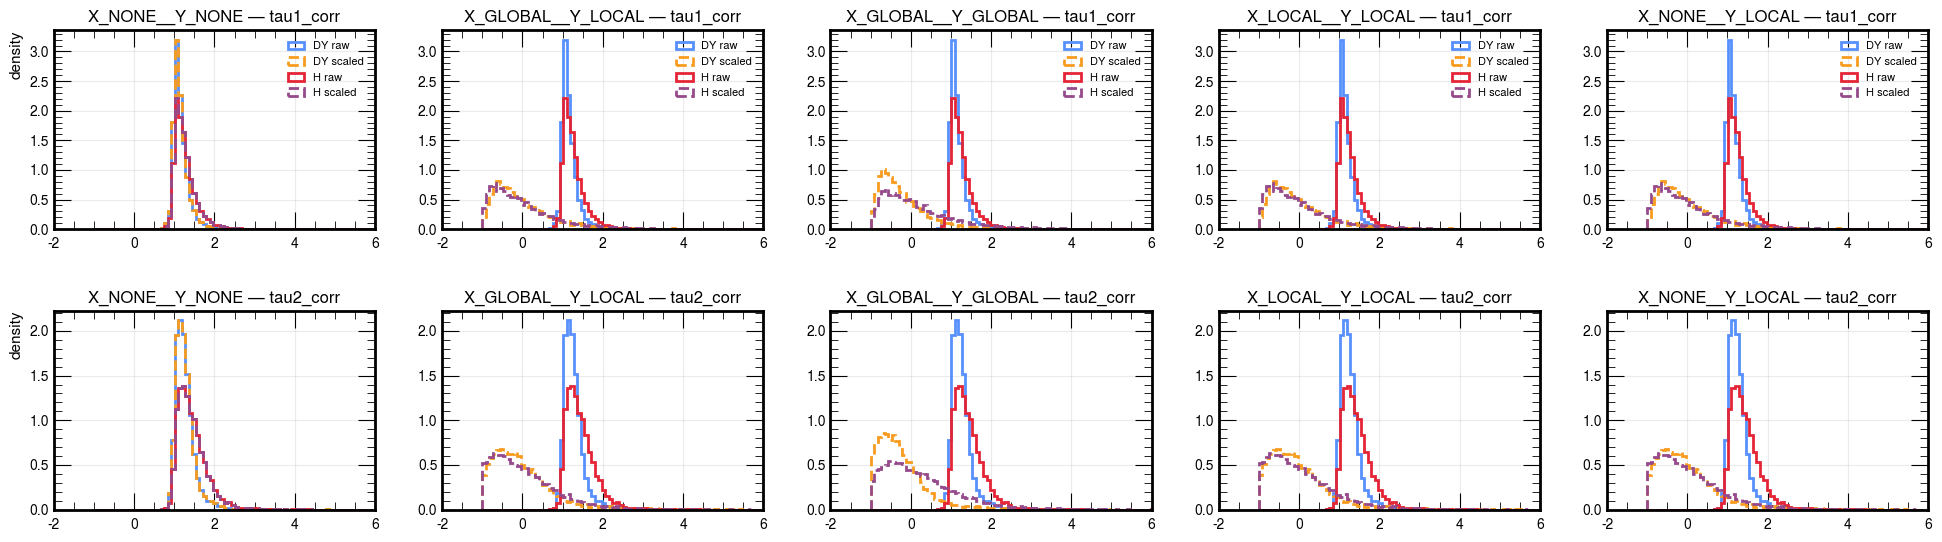

In [43]:
fig, axes = plt.subplots(2, len(SCALING_MODES), figsize=(20,6))

for j, mode in enumerate(SCALING_MODES):

    df_tr_s, df_va_s, df_te_s = results_balanced[mode]["df_splits_scaled"]

    for i, col in enumerate(y_cols):

        ax = axes[i, j]

        # DY raw
        ax.hist(
            df_test_bal[col][mask_dy],
            bins=80,
            range=(-1,6),
            density=True,
            histtype="step",
            lw=2,
            label="DY raw",
        )

        # DY scaled
        ax.hist(
            df_te_s[col][mask_dy],
            bins=80,
            range=(-1,6),
            density=True,
            histtype="step",
            lw=2,
            linestyle="--",
            label="DY scaled",
        )

        # H raw
        ax.hist(
            df_test_bal[col][mask_h],
            bins=80,
            range=(-1,6),
            density=True,
            histtype="step",
            lw=2,
            label="H raw",
        )

        # H scaled
        ax.hist(
            df_te_s[col][mask_h],
            bins=80,
            range=(-1,6),
            density=True,
            histtype="step",
            lw=2,
            linestyle="--",
            label="H scaled",
        )

        ax.set_xlim(-2,6)
        ax.set_title(f"{mode} — {col}")

        if j == 0:
            ax.set_ylabel("density")

        if i == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## y distribution pre/post inverse transform

In [48]:
# recupero le keys per ritrovare il nome degli scaler
for mode in SCALING_MODES:
    print("\n" + "="*80)
    print(mode)
    scalers = results_balanced[mode]["scalers"]
    print(type(scalers))
    if isinstance(scalers, dict):
        print("keys:", scalers.keys())
        for k, v in scalers.items():
            print(f"  {k}: {type(v)}")
    else:
        print(scalers)


X_NONE__Y_NONE
<class 'dict'>
keys: dict_keys(['mode', 'class_col', 'x_scale_cols', 'x_scaler', 'y_scaler'])
  mode: <class 'str'>
  class_col: <class 'str'>
  x_scale_cols: <class 'list'>
  x_scaler: <class 'NoneType'>
  y_scaler: <class 'NoneType'>

X_GLOBAL__Y_LOCAL
<class 'dict'>
keys: dict_keys(['mode', 'class_col', 'x_scale_cols', 'x_scaler', 'y_scaler'])
  mode: <class 'str'>
  class_col: <class 'str'>
  x_scale_cols: <class 'list'>
  x_scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
  y_scaler: <class 'dict'>

X_GLOBAL__Y_GLOBAL
<class 'dict'>
keys: dict_keys(['mode', 'class_col', 'x_scale_cols', 'x_scaler', 'y_scaler'])
  mode: <class 'str'>
  class_col: <class 'str'>
  x_scale_cols: <class 'list'>
  x_scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
  y_scaler: <class 'sklearn.preprocessing._data.StandardScaler'>

X_LOCAL__Y_LOCAL
<class 'dict'>
keys: dict_keys(['mode', 'class_col', 'x_scale_cols', 'x_scaler', 'y_scaler'])
  mode: <class 'str'>
  cla

In [49]:
for mode in SCALING_MODES:
    scalers = results_balanced[mode]["scalers"]
    print("\n" + "="*80)
    print(mode)
    print("mode in scalers:", scalers["mode"])
    print("type(y_scaler):", type(scalers["y_scaler"]))
    print("y_scaler:", scalers["y_scaler"])


X_NONE__Y_NONE
mode in scalers: X_NONE__Y_NONE
type(y_scaler): <class 'NoneType'>
y_scaler: None

X_GLOBAL__Y_LOCAL
mode in scalers: X_GLOBAL__Y_LOCAL
type(y_scaler): <class 'dict'>
y_scaler: {0: StandardScaler(), 1: StandardScaler()}

X_GLOBAL__Y_GLOBAL
mode in scalers: X_GLOBAL__Y_GLOBAL
type(y_scaler): <class 'sklearn.preprocessing._data.StandardScaler'>
y_scaler: StandardScaler()

X_LOCAL__Y_LOCAL
mode in scalers: X_LOCAL__Y_LOCAL
type(y_scaler): <class 'dict'>
y_scaler: {0: StandardScaler(), 1: StandardScaler()}

X_NONE__Y_LOCAL
mode in scalers: X_NONE__Y_LOCAL
type(y_scaler): <class 'dict'>
y_scaler: {0: StandardScaler(), 1: StandardScaler()}


In [50]:
def recover_y_inverse(df_scaled, scalers, y_cols, class_col="class"):
    df_inv = df_scaled.copy()

    mode = scalers["mode"]
    y_scaler = scalers["y_scaler"]

    # -------------------------
    # Y_NONE
    # -------------------------
    if y_scaler is None or mode.endswith("Y_NONE"):
        return df_inv

    # -------------------------
    # Y_GLOBAL
    # -------------------------
    if hasattr(y_scaler, "inverse_transform"):
        df_inv[y_cols] = y_scaler.inverse_transform(df_scaled[y_cols])
        return df_inv

    # -------------------------
    # Y_LOCAL
    # -------------------------
    if isinstance(y_scaler, dict):
        y_inv = df_scaled[y_cols].copy()

        for cls, scaler in y_scaler.items():
            mask = df_scaled[class_col] == cls
            if mask.any():
                y_inv.loc[mask, y_cols] = scaler.inverse_transform(
                    df_scaled.loc[mask, y_cols]
                )

        df_inv[y_cols] = y_inv
        return df_inv

    raise ValueError(f"Formato y_scaler non riconosciuto: {type(y_scaler)}")

In [51]:
for mode in SCALING_MODES:
    df_tr_s, df_va_s, df_te_s = results_balanced[mode]["df_splits_scaled"]
    scalers = results_balanced[mode]["scalers"]

    df_te_inv = recover_y_inverse(df_te_s, scalers, y_cols, class_col="class")

    print("\n" + "="*80)
    print(mode)

    for col in y_cols:
        diff = np.abs(df_te_inv[col].to_numpy() - df_test_bal[col].to_numpy())
        print(f"{col}: mean abs diff = {diff.mean():.3e} | max abs diff = {diff.max():.3e}")


X_NONE__Y_NONE
tau1_corr: mean abs diff = 0.000e+00 | max abs diff = 0.000e+00
tau2_corr: mean abs diff = 0.000e+00 | max abs diff = 0.000e+00

X_GLOBAL__Y_LOCAL
tau1_corr: mean abs diff = 6.096e-19 | max abs diff = 4.441e-16
tau2_corr: mean abs diff = 9.483e-19 | max abs diff = 4.441e-16

X_GLOBAL__Y_GLOBAL
tau1_corr: mean abs diff = 6.977e-19 | max abs diff = 8.882e-16
tau2_corr: mean abs diff = 1.389e-18 | max abs diff = 8.882e-16

X_LOCAL__Y_LOCAL
tau1_corr: mean abs diff = 6.096e-19 | max abs diff = 4.441e-16
tau2_corr: mean abs diff = 9.483e-19 | max abs diff = 4.441e-16

X_NONE__Y_LOCAL
tau1_corr: mean abs diff = 6.096e-19 | max abs diff = 4.441e-16
tau2_corr: mean abs diff = 9.483e-19 | max abs diff = 4.441e-16


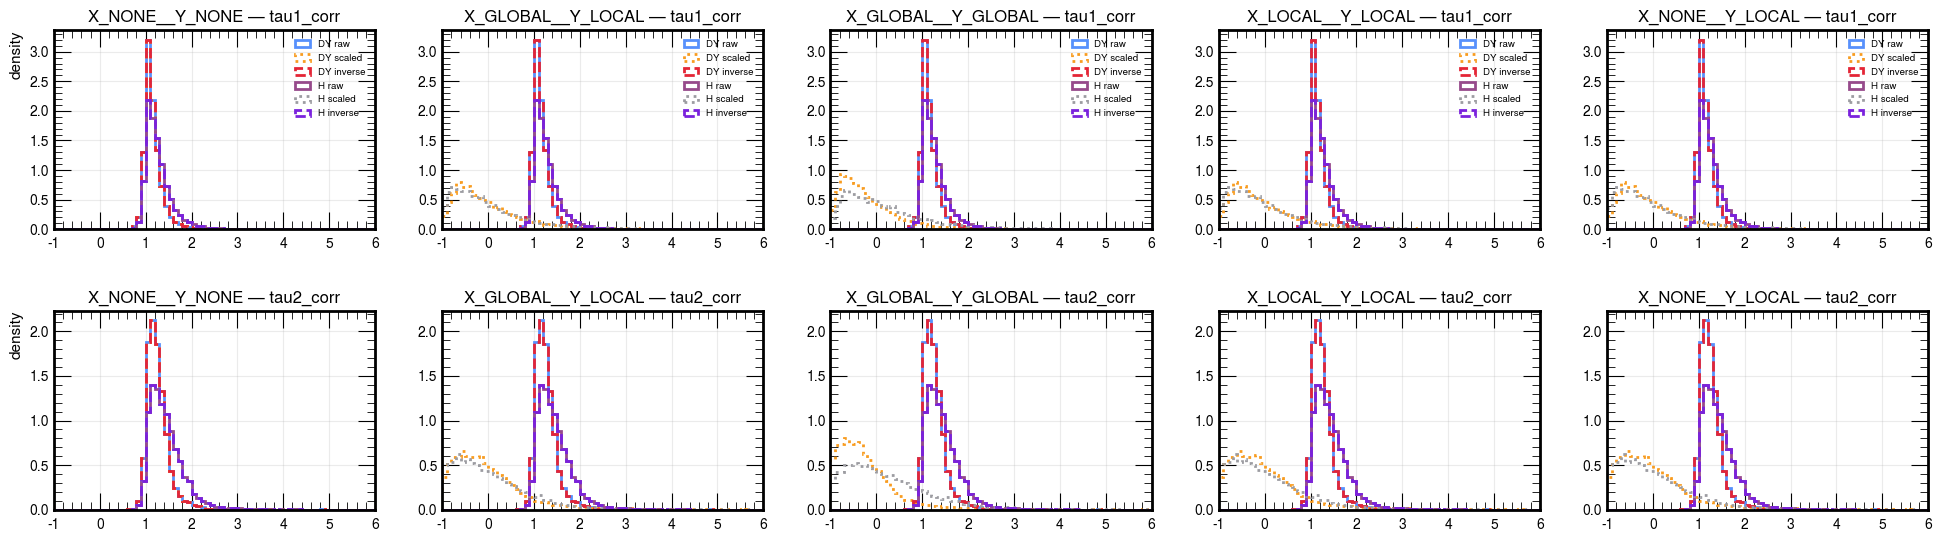

In [55]:
fig, axes = plt.subplots(2, len(SCALING_MODES), figsize=(20, 6))

for j, mode in enumerate(SCALING_MODES):
    df_tr_s, df_va_s, df_te_s = results_balanced[mode]["df_splits_scaled"]
    scalers = results_balanced[mode]["scalers"]

    df_te_inv = recover_y_inverse(df_te_s, scalers, y_cols, class_col="class")

    for i, col in enumerate(y_cols):
        ax = axes[i, j]

        ax.hist(
            df_test_bal.loc[mask_dy, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, label="DY raw"
        )

        ax.hist(
            df_te_s.loc[mask_dy, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, linestyle=":", label="DY scaled"
        )

        ax.hist(
            df_te_inv.loc[mask_dy, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, linestyle="--", label="DY inverse"
        )

        ax.hist(
            df_test_bal.loc[mask_h, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, label="H raw"
        )

        ax.hist(
            df_te_s.loc[mask_h, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, linestyle=":", label="H scaled"
        )

        ax.hist(
            df_te_inv.loc[mask_h, col],
            bins=80, range=(-2, 6), density=True,
            histtype="step", lw=2, linestyle="--", label="H inverse"
        )

        ax.set_xlim(-1, 6)
        ax.set_title(f"{mode} — {col}")

        if j == 0:
            ax.set_ylabel("density")
        if i == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

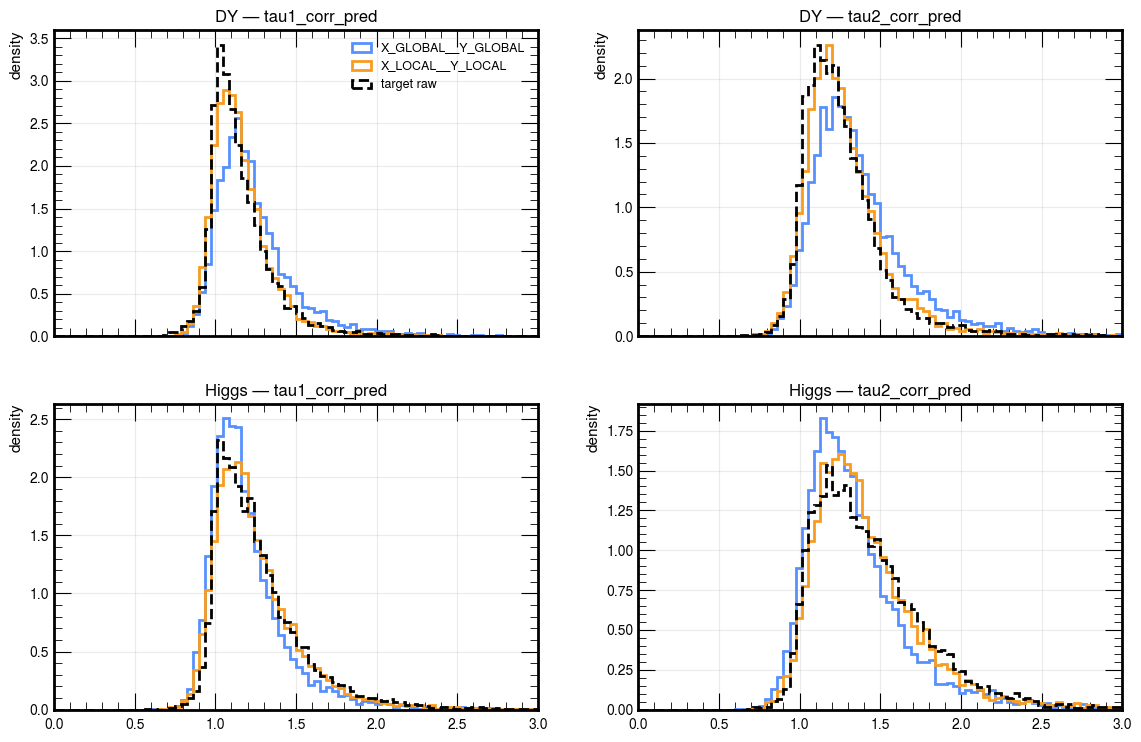

In [68]:
# aggiungo i target raw
pred_cols = ["tau1_corr_pred", "tau2_corr_pred"]
target_cols = ["tau1_corr", "tau2_corr"]

modes_to_compare = ["X_GLOBAL__Y_GLOBAL", "X_LOCAL__Y_LOCAL"]

fig, axes = plt.subplots(2, len(pred_cols), figsize=(12, 8), sharex=True)

samples = [
    ("DY", mask_dy),
    ("Higgs", mask_h),
]

for r, (sample_name, mask) in enumerate(samples):
    for i, col in enumerate(pred_cols):
        ax = axes[r, i]

        # predizioni
        for mode in modes_to_compare:
            df_pred = preds_bal[mode]

            ax.hist(
                df_pred.loc[mask, col],
                bins=80,
                range=(0, 3),
                density=True,
                histtype="step",
                lw=2,
                label=mode,
            )

        # target raw
        ax.hist(
            df_test_bal.loc[mask, target_cols[i]],
            bins=80,
            range=(0, 3),
            density=True,
            histtype="step",
            lw=2,
            linestyle="--",
            color="black",
            label="target raw",
        )

        ax.set_title(f"{sample_name} — {col}")
        ax.set_ylabel("density")
        ax.set_xlim(0, 3)

        if r == 0 and i == 0:
            ax.legend(fontsize=9)

plt.tight_layout()
plt.show()